<a href="https://colab.research.google.com/github/Lordyblade/BigData26_B_2411532010_IbrahimMousaDhani/blob/main/BD_B_T01_2411532010_Ibrahim_Mousa_Dhani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#J-2
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1/TugasPraktikum"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['agregasi_per_jam_juli.csv', 'agregasi_per_jam_juli.parquet', 'pengukuran_kinerja_juli.csv', 'distribusi_per_jam_juli.png', 'agregasi_per_jam.csv', 'perbandingan_januari_juli.png', 'perbandingan_januari_juli.csv']


In [ ]:
#J-3
import time, os, psutil
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2), "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS delta: {delta:+.1f} MB")
    return hasil

In [ ]:
#J-4
import urllib.request
URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-07.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

import pyarrow.parquet as pq
meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Ukuran file: 46.1 MB
Jumlah baris : 2,907,108
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [ ]:
#J-5
import pandas as pd
KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori:", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori:", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

# Penurunan Pemakaian Memori
sebelum = df.memory_usage(deep=True).sum() / 1024**2
df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")

for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

[baca semua kolom] 1.92 s | RSS delta: +482.1 MB
Dimensi: (2907108, 19)
Memori: 502.5 MB
[baca kolom terpilih] 1.82 s | RSS delta: +128.6 MB
Dimensi: (2907108, 8)
Memori: 177.4 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2907108 entries, 0 to 2907107
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 177.4 MB
177.4 MB -> 113.7 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


In [ ]:
#J-6
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom: \n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

       trip_distance  durasi_menit  total_amount
count   2.907108e+06  2.907108e+06  2.907108e+06
mean    4.489381e+00  1.707664e+01  2.856786e+01
std     2.578832e+02  4.099461e+01  2.446845e+01
min     0.000000e+00 -5.711667e+01 -6.223000e+02
25%     1.060000e+00  7.466667e+00  1.570000e+01
50%     1.810000e+00  1.240000e+01  2.090000e+01
75%     3.580000e+00  2.033333e+01  3.080000e+01
max     1.919450e+05  7.348833e+03  1.079450e+03

Nilai kosong per kolom: 
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          85086
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 49,790 baris (1.71%)
durasi <= 0           : 1,395 baris (0.05%)
durasi > 180 menit    : 2,760 baris (0.09%)
total_amount <= 0     : 31,240 baris (1.07%)
2,907,108 baris -> 2,817,657 baris (dibuang 89,451)


In [ ]:
#J-7
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))
print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 36.73 s | RSS delta: +5.7 MB
Parquet: 46.1 MB
CSV    : 213.6 MB
[agregasi chunking] 4.04 s | RSS delta: +27.5 MB
2,817,657 baris | rata-rata total_amount = 29.04


In [ ]:
#J-8
!pip install -q pyspark==3.5.1
!java -version

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
         - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
  SELECT payment_type,
       COUNT(*) AS jumlah,
       ROUND(AVG(total_amount), 2) AS rata_tarif,
       ROUND(AVG(tip_amount), 2) AS rata_tip
  FROM trips
  GROUP BY payment_type
  ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
Spark: 3.5.1
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |--

In [ ]:
#J-9
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam_juli.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_juli.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja_juli.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.049999,22.200001
1,1,59980,4.04,13.52,28.639999,21.360001
2,2,40812,3.79,12.82,27.080000,21.100000
3,3,26000,4.02,12.83,27.920000,21.299999
4,4,16637,5.60,14.62,34.919998,24.100000
5,5,16913,6.67,15.65,39.740002,23.900000
6,6,38422,5.11,14.51,32.130001,19.250000
7,7,69358,4.10,14.57,28.600000,18.799999
8,8,103647,3.53,15.30,27.340000,19.320000
9,9,118788,3.40,15.68,27.280001,19.900000


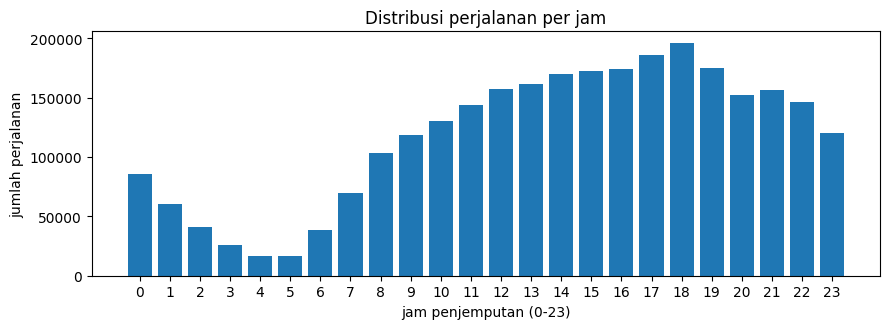

In [ ]:
#J-10
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("jam penjemputan (0-23)")
ax.set_ylabel("jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0,24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_juli.png", dpi=150)
plt.show()

=== Tabel perbandingan pola per jam: Januari vs Juli 2023 ===
 jam  jumlah_perjalanan_januari  jumlah_perjalanan_juli  selisih
   0                      82289                   85987     3698
   1                      57766                   59980     2214
   2                      40445                   40812      367
   3                      26146                   26000     -146
   4                      16618                   16637       19
   5                      16940                   16913      -27
   6                      42300                   38422    -3878
   7                      84569                   69358   -15211
   8                     114064                  103647   -10417
   9                     127988                  118788    -9200
  10                     140230                  130529    -9701
  11                     150539                  143780    -6759
  12                     165714                  157384    -8330
  13                     174

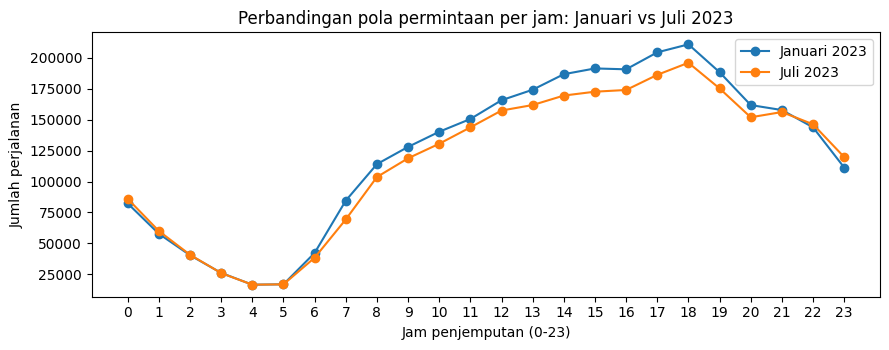

=== Laporan kinerja seluruh langkah (Juli) ===
            langkah  detik  delta_rss_mb
   baca semua kolom   1.92         482.1
baca kolom terpilih   1.82         128.6
          tulis CSV  36.73           5.7
  agregasi chunking   4.04          27.5
        spark count   3.16           0.0
     spark agregasi   5.08           0.0

Langkah paling mahal: 'tulis CSV' (36.73 detik, delta RSS 5.7 MB)


In [ ]:
# BANDINGKAN DUA BULAN (Januari vs Juli 2023)

# Membaca kembali hasil agregasi Januari (dari praktikum utama)
# dan hasil agregasi Juli (dari notebook tugas ini, variabel 'agregasi'
# hasil J-9 yang sudah dijalankan sebelumnya)
import shutil

SUMBER = "/content/drive/MyDrive/BigData/Praktikum1/agregasi_per_jam.csv"
TUJUAN = f"{DIR_SIMPAN}/agregasi_per_jam.csv"

if not os.path.exists(TUJUAN):
    shutil.copy(SUMBER, TUJUAN)

agregasi_jan = pd.read_csv(TUJUAN)

agregasi_jan = pd.read_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv")
agregasi_jul = agregasi.copy()   # hasil J-9 pada notebook tugas ini

perbandingan = agregasi_jan[["jam", "jumlah_perjalanan"]].merge(
    agregasi_jul[["jam", "jumlah_perjalanan"]],
    on="jam", suffixes=("_januari", "_juli"))
perbandingan["selisih"] = perbandingan["jumlah_perjalanan_juli"] - perbandingan["jumlah_perjalanan_januari"]

print("=== Tabel perbandingan pola per jam: Januari vs Juli 2023 ===")
print(perbandingan.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(perbandingan["jam"], perbandingan["jumlah_perjalanan_januari"], marker="o", label="Januari 2023")
ax.plot(perbandingan["jam"], perbandingan["jumlah_perjalanan_juli"], marker="o", label="Juli 2023")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Perbandingan pola permintaan per jam: Januari vs Juli 2023")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/perbandingan_januari_juli.png", dpi=150)
plt.show()

perbandingan.to_csv(f"{DIR_SIMPAN}/perbandingan_januari_juli.csv", index=False)


# LAPORAN KINERJA
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja_juli.csv", index=False)

kinerja = pd.DataFrame(catatan)
print("=== Laporan kinerja seluruh langkah (Juli) ===")
print(kinerja.to_string(index=False))

langkah_termahal = kinerja.loc[kinerja["detik"].idxmax()]
print(f"\nLangkah paling mahal: '{langkah_termahal['langkah']}' "
      f"({langkah_termahal['detik']} detik, delta RSS {langkah_termahal['delta_rss_mb']} MB)")